# 3D ResNet Overfit On 16 NIfTI Patients With Variable Depth


In [1]:
%pip install nibabel matplotlib openpyxl numpy


Looking in indexes: http://cor-notebook-dev-wheel-cache.projects:8081/simple, https://download.pytorch.org/whl/cu130
Looking in links: /var/cache/pip/wheels-local, /var/cache/pip/wheels
Note: you may need to restart the kernel to use updated packages.


## Paths And Config


In [2]:
from pathlib import Path

PROJECT_DIR = Path("/home/coder/project/jupyter")
BIN_DIR = PROJECT_DIR / "Bin_classification"
TRAIN_DIR = BIN_DIR / "Dataset_train_overfit_16_balanced_ich"
LABELS_XLSX = BIN_DIR / "overfit_16_balanced_ich.xlsx"
OUTPUT_DIR = BIN_DIR / "artifacts_resnet3d_overfit16_nii_variable_depth"

CONFIG = {
    "seed": 42,
    "device": "cuda",
    "target_column": "ICH",
    "image_size": 128,
    "batch_size": 1,
    "num_workers": 0,
    "epochs": 80,
    "learning_rate": 1e-4,
    "weight_decay": 0.0,
    "max_grad_norm": 5.0,
    "use_amp": False,
    "threshold": 0.7,
    "patience": 25,
    "resume_if_possible": False,
    "debug_batches": 2,
    "y_cap": 5.0,
}

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print("PROJECT_DIR =", PROJECT_DIR)
print("TRAIN_DIR   =", TRAIN_DIR)
print("LABELS_XLSX =", LABELS_XLSX)
print("OUTPUT_DIR  =", OUTPUT_DIR)


PROJECT_DIR = /home/coder/project/jupyter
TRAIN_DIR   = /home/coder/project/jupyter/Bin_classification/Dataset_train_overfit_16_balanced_ich
LABELS_XLSX = /home/coder/project/jupyter/Bin_classification/overfit_16_balanced_ich.xlsx
OUTPUT_DIR  = /home/coder/project/jupyter/Bin_classification/artifacts_resnet3d_overfit16_nii_variable_depth


## Imports


In [3]:
import json
import math
import random
import time

import matplotlib.pyplot as plt
import nibabel as nib
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from IPython.display import clear_output, display
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score
from torch.optim import AdamW
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm


/home/coder/python-packages/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Helpers


In [4]:
def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def log_debug(message: str, debug_log_path: Path | None = None) -> None:
    if debug_log_path is not None:
        with debug_log_path.open('a', encoding='utf-8') as f:
            f.write(message + "\n")

def tensor_stats_logged(name: str, x: torch.Tensor, debug_log_path: Path | None = None) -> None:
    x_detached = x.detach()
    if x_detached.numel() == 1:
        message = (
            f"{name}: shape={tuple(x_detached.shape)} "
            f"min={x_detached.min().item():.4f} "
            f"max={x_detached.max().item():.4f} "
            f"mean={x_detached.mean().item():.4f} "
            f"std=nan"
        )
    else:
        message = (
            f"{name}: shape={tuple(x_detached.shape)} "
            f"min={x_detached.min().item():.4f} "
            f"max={x_detached.max().item():.4f} "
            f"mean={x_detached.mean().item():.4f} "
            f"std={x_detached.std().item():.4f}"
        )
    log_debug(message, debug_log_path)

def build_records(images_dir: Path, labels_xlsx: Path, target_column: str) -> list[dict[str, object]]:
    labels_df = pd.read_excel(labels_xlsx)
    labels_df['study_uid'] = labels_df['study_uid'].astype(str)
    records = []
    for _, row in labels_df.iterrows():
        study_uid = str(row['study_uid'])
        image_path = images_dir / f'{study_uid}.nii.gz'
        if image_path.exists():
            records.append(
                {
                    'study_uid': study_uid,
                    'image_path': image_path,
                    'target': float(row[target_column]),
                }
            )
    return records


def summarize_targets(records: list[dict[str, object]]) -> pd.DataFrame:
    targets = np.asarray([record['target'] for record in records], dtype=np.float32)
    return pd.DataFrame(
        {
            'count': [len(targets)],
            'positive_cases': [int(targets.sum())],
            'positive_rate': [float(targets.mean()) if len(targets) else float('nan')],
        }
    )

## Dataset


In [5]:
class NiftiVolumeDataset(Dataset):
    def __init__(self, records: list[dict[str, object]], image_size: int) -> None:
        self.records = records
        self.image_size = image_size

    def __len__(self) -> int:
        return len(self.records)

    def _resize_xy(self, tensor: torch.Tensor) -> torch.Tensor:
        depth = tensor.shape[0]
        tensor = tensor.unsqueeze(0).unsqueeze(0)
        tensor = F.interpolate(
            tensor,
            size=(depth, self.image_size, self.image_size),
            mode='trilinear',
            align_corners=False,
        )
        return tensor.squeeze(0).squeeze(0)

    def __getitem__(self, index: int) -> dict[str, object]:
        record = self.records[index]
        volume = nib.load(str(record['image_path'])).get_fdata(dtype='float32')
        tensor = torch.from_numpy(volume).permute(2, 0, 1).contiguous()
        tensor = torch.nan_to_num(tensor, nan=0.0, posinf=0.0, neginf=0.0)
        tensor = self._resize_xy(tensor)
        image = tensor.unsqueeze(0)
        return {
            'image': image,
            'target': torch.tensor([record['target']], dtype=torch.float32),
            'study_uid': record['study_uid'],
            'depth': tensor.shape[0],
        }


def collate_batch_size_one(batch: list[dict[str, object]]) -> dict[str, object]:
    if len(batch) != 1:
        raise RuntimeError('This notebook expects batch_size = 1 for variable depth volumes.')
    item = batch[0]
    return {
        'image': item['image'].unsqueeze(0),
        'target': item['target'].unsqueeze(0),
        'study_uid': [item['study_uid']],
        'depth': [item['depth']],
    }


## Model


In [6]:
class BasicBlock3D(nn.Module):
    expansion = 1

    def __init__(self, in_planes: int, planes: int, stride=1) -> None:
        super().__init__()
        self.conv1 = nn.Conv3d(in_planes, planes, kernel_size=3, stride=stride, padding=1, bias=False)
        self.gn1 = nn.GroupNorm(8, planes)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv3d(planes, planes, kernel_size=3, stride=1, padding=1, bias=False)
        self.gn2 = nn.GroupNorm(8, planes)

        if stride != 1 or in_planes != planes:
            self.downsample = nn.Sequential(
                nn.Conv3d(in_planes, planes, kernel_size=1, stride=stride, bias=False),
                nn.GroupNorm(8, planes),
            )
        else:
            self.downsample = None

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        identity = x
        out = self.conv1(x)
        out = self.gn1(out)
        out = self.relu(out)
        out = self.conv2(out)
        out = self.gn2(out)

        if self.downsample is not None:
            identity = self.downsample(identity)

        out = out + identity
        out = self.relu(out)
        return out


class ResNet3DSmall(nn.Module):
    def __init__(self) -> None:
        super().__init__()
        self.in_planes = 16
        self.stem = nn.Sequential(
            nn.Conv3d(1, 16, kernel_size=7, stride=(1, 2, 2), padding=3, bias=False),
            nn.GroupNorm(8, 16),
            nn.ReLU(inplace=True),
            nn.MaxPool3d(kernel_size=3, stride=(1, 2, 2), padding=1),
        )
        self.layer1 = self._make_layer(16, blocks=2, stride=1)
        self.layer2 = self._make_layer(32, blocks=2, stride=2)
        self.layer3 = self._make_layer(64, blocks=2, stride=2)
        self.layer4 = self._make_layer(128, blocks=2, stride=2)
        self.pool = nn.AdaptiveAvgPool3d((1, 1, 1))
        self.dropout = nn.Dropout(0.0)
        self.fc = nn.Linear(128, 1)

    def _make_layer(self, planes: int, blocks: int, stride: int) -> nn.Sequential:
        layers = [BasicBlock3D(self.in_planes, planes, stride=stride)]
        self.in_planes = planes
        for _ in range(1, blocks):
            layers.append(BasicBlock3D(self.in_planes, planes, stride=1))
        return nn.Sequential(*layers)

    def forward(self, x: torch.Tensor, debug: bool = False, debug_log_path: Path | None = None) -> torch.Tensor:
        x = self.stem(x)
        if debug:
            tensor_stats_logged('stem', x, debug_log_path)

        x = self.layer1(x)
        if debug:
            tensor_stats_logged('layer1', x, debug_log_path)

        x = self.layer2(x)
        if debug:
            tensor_stats_logged('layer2', x, debug_log_path)

        x = self.layer3(x)
        if debug:
            tensor_stats_logged('layer3', x, debug_log_path)

        x = self.layer4(x)
        if debug:
            tensor_stats_logged('layer4', x, debug_log_path)

        x = self.pool(x).flatten(1)
        if debug:
            tensor_stats_logged('pool_flat', x, debug_log_path)

        x = self.dropout(x)
        logits = self.fc(x)
        if debug:
            tensor_stats_logged('logits', logits, debug_log_path)
        return logits

## Build Records And Loaders


In [7]:
set_seed(CONFIG['seed'])

records = build_records(TRAIN_DIR, LABELS_XLSX, CONFIG['target_column'])
train_records = records

print('Train split:', len(train_records))
display(summarize_targets(train_records).rename(index={0: 'train'}))
print('Patients:', [record['study_uid'] for record in train_records])

train_dataset = NiftiVolumeDataset(train_records, CONFIG['image_size'])

train_loader = DataLoader(
    train_dataset,
    batch_size=CONFIG['batch_size'],
    shuffle=False,
    num_workers=CONFIG['num_workers'],
    pin_memory=False,
    collate_fn=collate_batch_size_one,
)

sample = train_dataset[0]
print('Sample image shape:', tuple(sample['image'].shape))
print('Sample target:', sample['target'].item())
print('Sample study_uid:', sample['study_uid'])
print('Sample depth:', sample['depth'])

Train split: 16


,count,positive_cases,positive_rate
train,16,8,0.5


Patients: ['1.2.643.5.1.13.13.12.2.77.8252.14130903121503031302001304120909', '1.2.643.5.1.13.13.12.2.77.8252.14001507020807131402151406001108', '1.2.643.5.1.13.13.12.2.77.8252.13141114100702070802081000020215', '1.2.643.5.1.13.13.12.2.77.8252.13020108050607090109010007150908', '1.2.643.5.1.13.13.12.2.77.8252.12130713100607060005081306080611', '1.2.643.5.1.13.13.12.2.77.8252.11000800140601110907081215061100', '1.2.643.5.1.13.13.12.2.77.8252.10151303040713040506100903000600', '1.2.643.5.1.13.13.12.2.77.8252.09130006030915040603130301000603', '1.2.643.5.1.13.13.12.2.77.8252.09080714061511080607121015090605', '1.2.643.5.1.13.13.12.2.77.8252.08041213001104110103010007010602', '1.2.643.5.1.13.13.12.2.77.8252.06000111071507040610090702150509', '1.2.643.5.1.13.13.12.2.77.8252.05110101030403050600050503110001', '1.2.643.5.1.13.13.12.2.77.8252.02051011031008091210070605060112', '1.2.643.5.1.13.13.12.2.77.8252.01070007070308031013141103140614', '1.2.643.5.1.13.13.12.2.77.8252.0009021312111305040

## Metrics And Plotting


In [8]:
def compute_binary_metrics(y_true: np.ndarray, y_prob: np.ndarray, threshold: float = 0.5) -> dict[str, float]:
    y_pred = (y_prob >= threshold).astype(np.int32)
    metrics = {
        'accuracy': float(accuracy_score(y_true, y_pred)),
        'f1': float(f1_score(y_true, y_pred, zero_division=0)),
        'precision': float(precision_score(y_true, y_pred, zero_division=0)),
        'recall': float(recall_score(y_true, y_pred, zero_division=0)),
        'incorrect_studies': int((y_true != y_pred).sum()),
    }
    try:
        metrics['roc_auc'] = float(roc_auc_score(y_true, y_prob))
    except ValueError:
        metrics['roc_auc'] = float('nan')
    return metrics


def draw_training_dashboard(
    train_iter_losses: list[dict],
    history: list[dict],
    title: str,
    output_path: Path,
    y_cap: float,
) -> None:
    train_df = pd.DataFrame(train_iter_losses)
    history_df = pd.DataFrame(history)

    fig, axes = plt.subplots(2, 1, figsize=(20, 12))

    if not train_df.empty:
        normal = train_df[train_df['loss'] <= y_cap]
        outliers = train_df[train_df['loss'] > y_cap]
        axes[0].plot(normal['iteration'], normal['loss'], label='train_loss', color='tab:blue', linewidth=1.5)
        if not outliers.empty:
            axes[0].scatter(outliers['iteration'], [y_cap] * len(outliers), color='tab:blue', s=28)
            for _, row in outliers.iterrows():
                axes[0].annotate(
                    f"{row['loss']:.1f}",
                    (row['iteration'], y_cap),
                    textcoords='offset points',
                    xytext=(0, 6),
                    ha='center',
                    fontsize=8,
                    color='tab:blue',
                )

    axes[0].set_xlabel('Iteration')
    axes[0].set_ylabel('Loss')
    axes[0].set_ylim(0, y_cap)
    axes[0].set_title(title)
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()

    if not history_df.empty:
        axes[1].plot(history_df['epoch'], history_df['train_f1'], label='train_f1', color='tab:blue', linewidth=2, marker='o')
        axes[1].plot(history_df['epoch'], history_df['train_accuracy'], label='train_accuracy', color='tab:green', linewidth=1.5, marker='o')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Metric')
    axes[1].set_ylim(0, 1.05)
    axes[1].set_title('3D ResNet train metrics by epoch')
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()

    fig.tight_layout()
    fig.savefig(output_path, dpi=150)
    clear_output(wait=True)
    display(fig)
    plt.close(fig)

## Train Loop


In [9]:
def run_one_epoch(
    model: nn.Module,
    loader: DataLoader,
    criterion: nn.Module,
    device: torch.device,
    optimizer: torch.optim.Optimizer | None,
    threshold: float,
    max_grad_norm: float | None,
    stage: str,
    start_iteration: int,
    train_iter_losses: list[dict],
    history: list[dict],
    plot_path: Path,
    debug_batches: int,
    y_cap: float,
    debug_log_path: Path | None,
) -> tuple[dict[str, float], int]:
    training = optimizer is not None
    model.train(training)
    total_loss = 0.0
    total_items = 0
    probs_list = []
    targets_list = []

    if training:
        optimizer.zero_grad(set_to_none=True)

    progress = tqdm(loader, leave=False)
    current_iteration = start_iteration
    for local_step, batch in enumerate(progress, start=1):
        current_iteration += 1
        images = batch['image'].to(device)
        targets = batch['target'].to(device)
        debug_now = local_step <= debug_batches

        with torch.set_grad_enabled(training):
            logits = model(images, debug=debug_now, debug_log_path=debug_log_path)
            loss = criterion(logits, targets)

        if training:
            loss.backward()
            if debug_now:
                total_grad_norm_sq = 0.0
                for p in model.parameters():
                    if p.grad is not None:
                        param_norm = p.grad.detach().data.norm(2).item()
                        total_grad_norm_sq += param_norm ** 2
                total_grad_norm = total_grad_norm_sq ** 0.5
                log_debug(f'grad_norm_total: {total_grad_norm:.6f}', debug_log_path)
                if model.fc.weight.grad is not None:
                    log_debug(f'fc.weight grad norm: {model.fc.weight.grad.detach().data.norm(2).item():.6f}', debug_log_path)
                if model.fc.bias.grad is not None:
                    log_debug(f'fc.bias grad norm: {model.fc.bias.grad.detach().data.norm(2).item():.6f}', debug_log_path)
            if max_grad_norm is not None:
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
            optimizer.step()
            optimizer.zero_grad(set_to_none=True)

        probs = torch.sigmoid(logits).detach().cpu().numpy().reshape(-1)
        target_values = targets.detach().cpu().numpy().reshape(-1)
        probs_list.append(probs)
        targets_list.append(target_values)

        if debug_now:
            preds = (probs >= threshold).astype(np.float32)
            log_debug(f'stage: {stage}', debug_log_path)
            log_debug(f"study_uid: {batch['study_uid']}", debug_log_path)
            log_debug(f"depth: {batch['depth']}", debug_log_path)
            log_debug(f'targets: {target_values.tolist()}', debug_log_path)
            log_debug(f"logits: {logits.detach().cpu().numpy().reshape(-1).tolist()}", debug_log_path)
            log_debug(f'probs: {probs.tolist()}', debug_log_path)
            log_debug(f'preds: {preds.tolist()}', debug_log_path)
            log_debug(f"image shape: {tuple(batch['image'].shape)}", debug_log_path)
            log_debug('-' * 80, debug_log_path)

        batch_size = targets.shape[0]
        batch_loss = float(loss.detach().item())
        total_loss += batch_loss * batch_size
        total_items += batch_size

        entry = {
            'stage': stage,
            'iteration': current_iteration,
            'epoch_local_iteration': local_step,
            'loss': batch_loss,
        }
        train_iter_losses.append(entry)

        draw_training_dashboard(train_iter_losses, history, '3D ResNet train loss by iteration', plot_path, y_cap)
        progress.set_postfix(loss=f'{batch_loss:.4f}')

    y_true = np.concatenate(targets_list)
    y_prob = np.concatenate(probs_list)
    metrics = compute_binary_metrics(y_true, y_prob, threshold)
    metrics['loss'] = float(total_loss / max(total_items, 1))
    return metrics, current_iteration

## Run Training


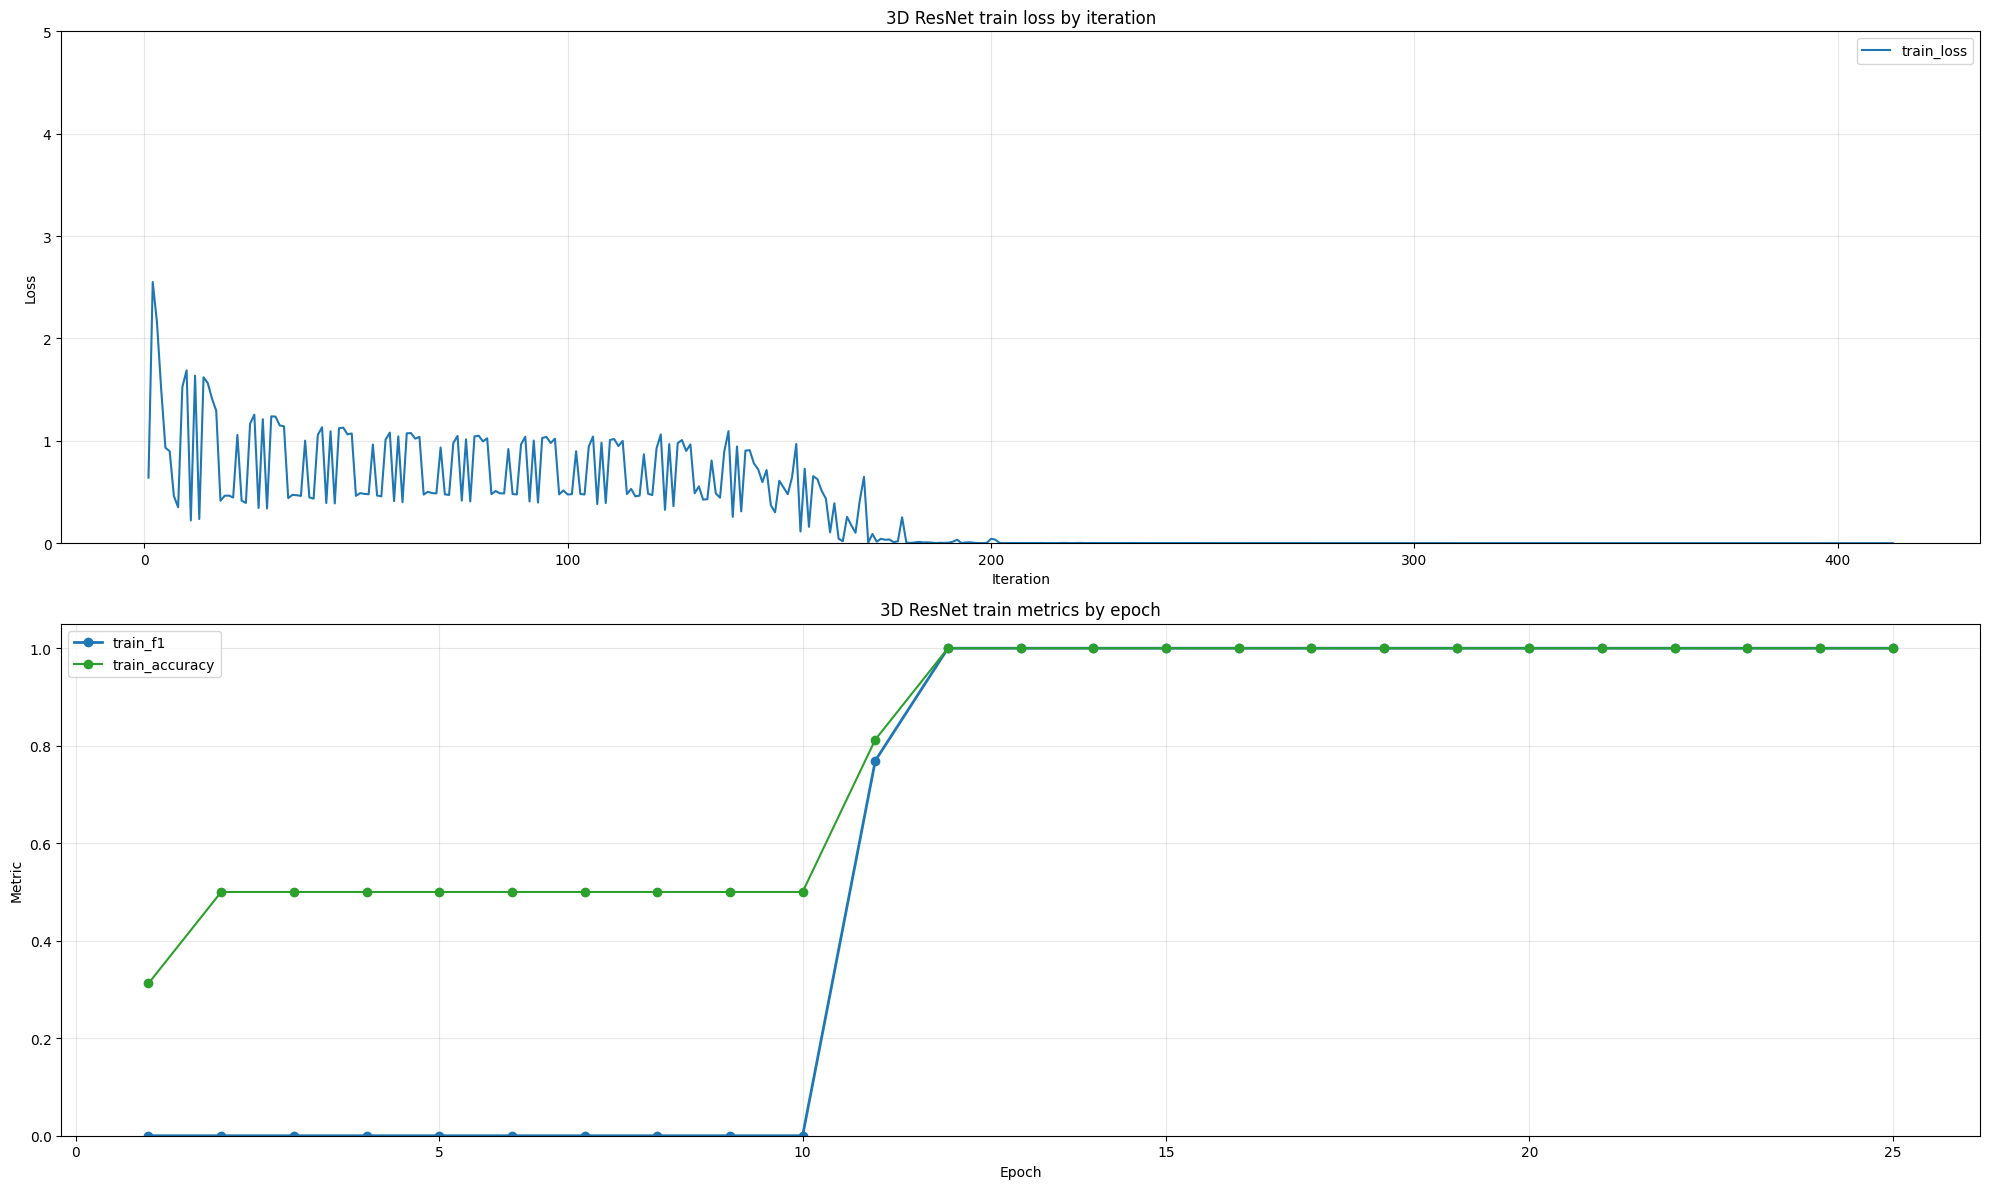

KeyboardInterrupt: 

In [10]:
device = torch.device(CONFIG['device'] if torch.cuda.is_available() else 'cpu')
model = ResNet3DSmall().to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = AdamW(model.parameters(), lr=CONFIG['learning_rate'], weight_decay=CONFIG['weight_decay'])

history = []
train_iter_losses = []
history_csv_path = OUTPUT_DIR / 'history_resnet3d_overfit16_nii_variable_depth.csv'
history_json_path = OUTPUT_DIR / 'history_resnet3d_overfit16_nii_variable_depth.json'
train_iter_csv_path = OUTPUT_DIR / 'train_iteration_losses_resnet3d_overfit16_nii_variable_depth.csv'
best_ckpt_path = OUTPUT_DIR / 'checkpoint_best_resnet3d_overfit16_nii_variable_depth.pt'
last_ckpt_path = OUTPUT_DIR / 'checkpoint_last_resnet3d_overfit16_nii_variable_depth.pt'
loss_plot_path = OUTPUT_DIR / 'loss_curve_resnet3d_overfit16_nii_variable_depth.png'
debug_log_path = OUTPUT_DIR / 'debug_forward_backward.txt'
debug_log_path.write_text('', encoding='utf-8')

best_train_f1 = -math.inf
epochs_without_improvement = 0
global_train_iteration = 0
start_epoch = 1

if CONFIG['resume_if_possible'] and last_ckpt_path.exists():
    checkpoint = torch.load(last_ckpt_path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    history = checkpoint.get('history', [])
    best_train_f1 = checkpoint.get('best_train_f1', best_train_f1)
    epochs_without_improvement = checkpoint.get('epochs_without_improvement', 0)
    global_train_iteration = checkpoint.get('global_train_iteration', 0)
    start_epoch = int(checkpoint.get('epoch', 0)) + 1
    if train_iter_csv_path.exists():
        train_iter_losses = pd.read_csv(train_iter_csv_path).to_dict('records')
    print(f'Resuming from epoch {start_epoch}')

for epoch in range(start_epoch, CONFIG['epochs'] + 1):
    epoch_started = time.time()
    train_metrics, global_train_iteration = run_one_epoch(
        model=model,
        loader=train_loader,
        criterion=criterion,
        device=device,
        optimizer=optimizer,
        threshold=CONFIG['threshold'],
        max_grad_norm=CONFIG['max_grad_norm'],
        stage='train',
        start_iteration=global_train_iteration,
        train_iter_losses=train_iter_losses,
        history=history,
        plot_path=loss_plot_path,
        debug_batches=CONFIG['debug_batches'],
        y_cap=CONFIG['y_cap'],
        debug_log_path=debug_log_path,
    )

    row = {
        'epoch': epoch,
        'train_loss': train_metrics['loss'],
        'train_accuracy': train_metrics['accuracy'],
        'train_f1': train_metrics['f1'],
        'train_precision': train_metrics['precision'],
        'train_recall': train_metrics['recall'],
        'train_roc_auc': train_metrics['roc_auc'],
        'train_incorrect_studies': train_metrics['incorrect_studies'],
        'epoch_minutes': (time.time() - epoch_started) / 60.0,
    }
    history.append(row)

    if row['train_f1'] > best_train_f1:
        best_train_f1 = row['train_f1']
        epochs_without_improvement = 0
        torch.save(
            {
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'config': CONFIG,
                'history': history,
                'best_train_f1': best_train_f1,
                'epochs_without_improvement': epochs_without_improvement,
                'global_train_iteration': global_train_iteration,
            },
            best_ckpt_path,
        )
    else:
        epochs_without_improvement += 1

    torch.save(
        {
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'config': CONFIG,
            'history': history,
            'best_train_f1': best_train_f1,
            'epochs_without_improvement': epochs_without_improvement,
            'global_train_iteration': global_train_iteration,
        },
        last_ckpt_path,
    )

    pd.DataFrame(history).to_csv(history_csv_path, index=False)
    pd.DataFrame(train_iter_losses).to_csv(train_iter_csv_path, index=False)
    history_json_path.write_text(
        json.dumps({'history': history, 'best_train_f1': best_train_f1}, ensure_ascii=False, indent=2),
        encoding='utf-8',
    )

    draw_training_dashboard(train_iter_losses, history, '3D ResNet NIfTI overfit16 train loss by iteration', loss_plot_path, CONFIG['y_cap'])
    print(
        f"Epoch {epoch:03d} | train_loss={row['train_loss']:.4f} | train_acc={row['train_accuracy']:.4f} | "
        f"train_f1={row['train_f1']:.4f} | train_wrong={row['train_incorrect_studies']}"
    )

    if epochs_without_improvement >= CONFIG['patience']:
        print('Early stopping: train F1 did not improve.')
        break

draw_training_dashboard(train_iter_losses, history, '3D ResNet NIfTI overfit16 train loss by iteration', loss_plot_path, CONFIG['y_cap'])
display(pd.DataFrame(history).tail())